In [1]:
    import numpy as np
    import pylab as plt
    import pyccl as ccl
    import pyccl.nl_pt as pt
    import pyccl.ccllib as lib
    from astropy import units as u
    from astropy.coordinates import Angle
    %pylab inline 
    from astropy.table import Table

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/global/common/software/lsst/common/miniconda/dp-v0.0.42-d/lib/python3.8/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['plt']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [3]:
#OuterRim:
cosmo = ccl.Cosmology(Omega_c=0.22, Omega_b=0.0448, 
    h=0.71, sigma8 = 0.801, n_s= 0.963,w0=-1.00,wa=0.0, Omega_k=0.0)
 

In [4]:
nzs=np.loadtxt("/global/homes/j/jharno/IA-infusion/SkySim5000/tools/SkySim5000_IA_infusion/StageIV_zcen_nz_bin1-5.dat", unpack = True)

In [6]:
z=nzs[0]
nzs_s=nzs[1:]

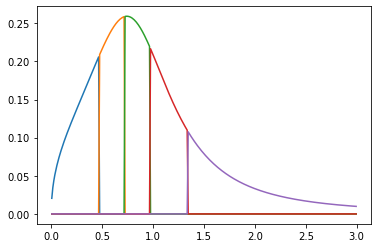

In [7]:
for i in range(len(nzs_s)):
    plot(z,nzs_s[i])

In [8]:
# IA normalization
#these factors absorb the typical normalization factors used in the literature 
#for intrinsic alignment amplitude and redshift evolution.
# Biases for IAs. Will be converted to the input c_IA values below.\n",
a_1 = 1.0
a_2 = 0.0
a_d = 0.0

In [10]:
c_1,c_d,c_2 = pt.translate_IA_norm(cosmo, z, a1=a_1,
                     Om_m2_for_c2 = False)

In [11]:
# Tracers
#Let's create the 3 PTTracers

#Intrinsic alignments
ptt_i = pt.PTIntrinsicAlignmentTracer(c1=(z,c_1), c2=None, cdelta=None)
ptt_i_nla = pt.PTIntrinsicAlignmentTracer(c1=(z,c_1)) # to compare using the standard WLTracer\n",

# Matter
ptt_m = pt.PTMatterTracer()

In [12]:
ptc = pt.PTCalculator(with_NC=True, with_IA=True,
         log10k_min=-5, log10k_max=3, low_extrap=-5, high_extrap=5, nk_per_decade=20)

In [14]:
# PT power spectra

# IAs x IAs
pk_ii, pk_ii_bb = pt.get_pt_pk2d(cosmo, ptt_i, tracer2=ptt_i, ptc=ptc, return_ia_ee_and_bb=True)
pk_ii_nla = pt.get_pt_pk2d(cosmo, ptt_i_nla, tracer2=ptt_i_nla, ptc=ptc,)
    
# IAs x matter
pk_im = pt.get_pt_pk2d(cosmo, ptt_i, tracer2=ptt_m, ptc=ptc)
    
# Matter x matter
pk_mm = pt.get_pt_pk2d(cosmo, ptt_m, tracer2=ptt_m, ptc=ptc)

In [15]:
ks = np.logspace(-4,2,512)
ps = {}
ps['ii'] = pk_ii.eval(ks, 1., cosmo)
ps['im'] = pk_im.eval(ks, 1., cosmo)
ps['mm'] = pk_mm.eval(ks, 1., cosmo)

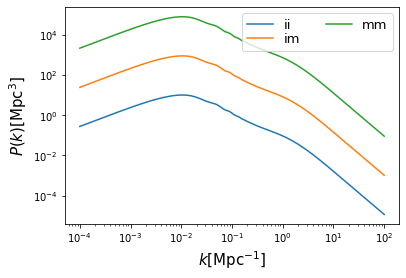

In [19]:
plt.figure()
for pn, p in ps.items():
    plt.plot(ks, abs(p), label=pn)
plt.loglog()
plt.legend(loc='upper right', ncol=2,
    fontsize=13, labelspacing=0.1)
plt.xlabel(r'$k [{\rm Mpc}^{-1}]$', fontsize=15)
plt.ylabel(r'$P(k)[{\rm Mpc}^{3}]$', fontsize=15)
plt.show()

In [20]:
# Angular power spectra
# Lensing
tracers_len = []
    
for i in range(len(nzs_s)):
    t_l = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[i]))
    tracers_len.append(t_l)

In [21]:
# Intrinsic alignments
tracers_IA = []
for i in range(len(nzs_s)):
    t_i = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[i]), has_shear=False, ia_bias=(z, np.ones_like(z)), use_A_ia=False)
    tracers_IA.append(t_i)

In [22]:
# Intrinsic alignments
tracers_IA_nla = []
for i in range(len(nzs_s)):
    t_i_nla = ccl.WeakLensingTracer(cosmo, dndz=(z, nzs_s[i]), has_shear=False, ia_bias=(z, np.ones_like(z)), use_A_ia=True)
    tracers_IA_nla.append(t_i_nla)

In [25]:
ell = np.unique(np.geomspace(2,300000,10000).astype(int)).astype(float)
cls={}
    
    
cross=[]
for i in range(5):
    for j in range(i+1):
        cross.append(ccl.angular_cl(cosmo, tracers_len[i], tracers_len[j], ell,p_of_k_a=pk_mm))
cls['GG'] = np.stack(cross)
    
cross=[]
for i in range(5):
    for j in range(i+1):
        cross.append(ccl.angular_cl(cosmo, tracers_IA[i], tracers_IA[j], ell,p_of_k_a=pk_ii))
cls['II'] = np.stack(cross)
    
cross=[]
for i in range(5):
    for j in range(i+1):
        cross.append(ccl.angular_cl(cosmo, tracers_IA_nla[i], tracers_IA_nla[j], ell))
cls['II,NLA'] = np.stack(cross)
    
    
cross=[]
for i in range(5):
    for j in range(i+1):
        cross.append(ccl.angular_cl(cosmo, tracers_len[i],tracers_IA[j], ell, p_of_k_a=pk_im))
cls['GI'] =np.stack(cross)
    
    
cross=[]
for i in range(5):
    for j in range(i+1):
        cross.append(ccl.angular_cl(cosmo, tracers_len[i],tracers_IA_nla[j], ell))
cls['GI,NLA'] =np.stack(cross)

In [26]:
def trim_axs(axs, N):

    #Reduce *axs* to *N* Axes. All further Axes are removed from the figure.
    axs = axs.flat
    for ax in axs[N:]:
        ax.remove()
        plt.xlabel(r'$\\theta$', fontsize=15)
        plt.ylabel(r'$\\xi_+(\\theta)$', fontsize=15)
    return axs[:N]

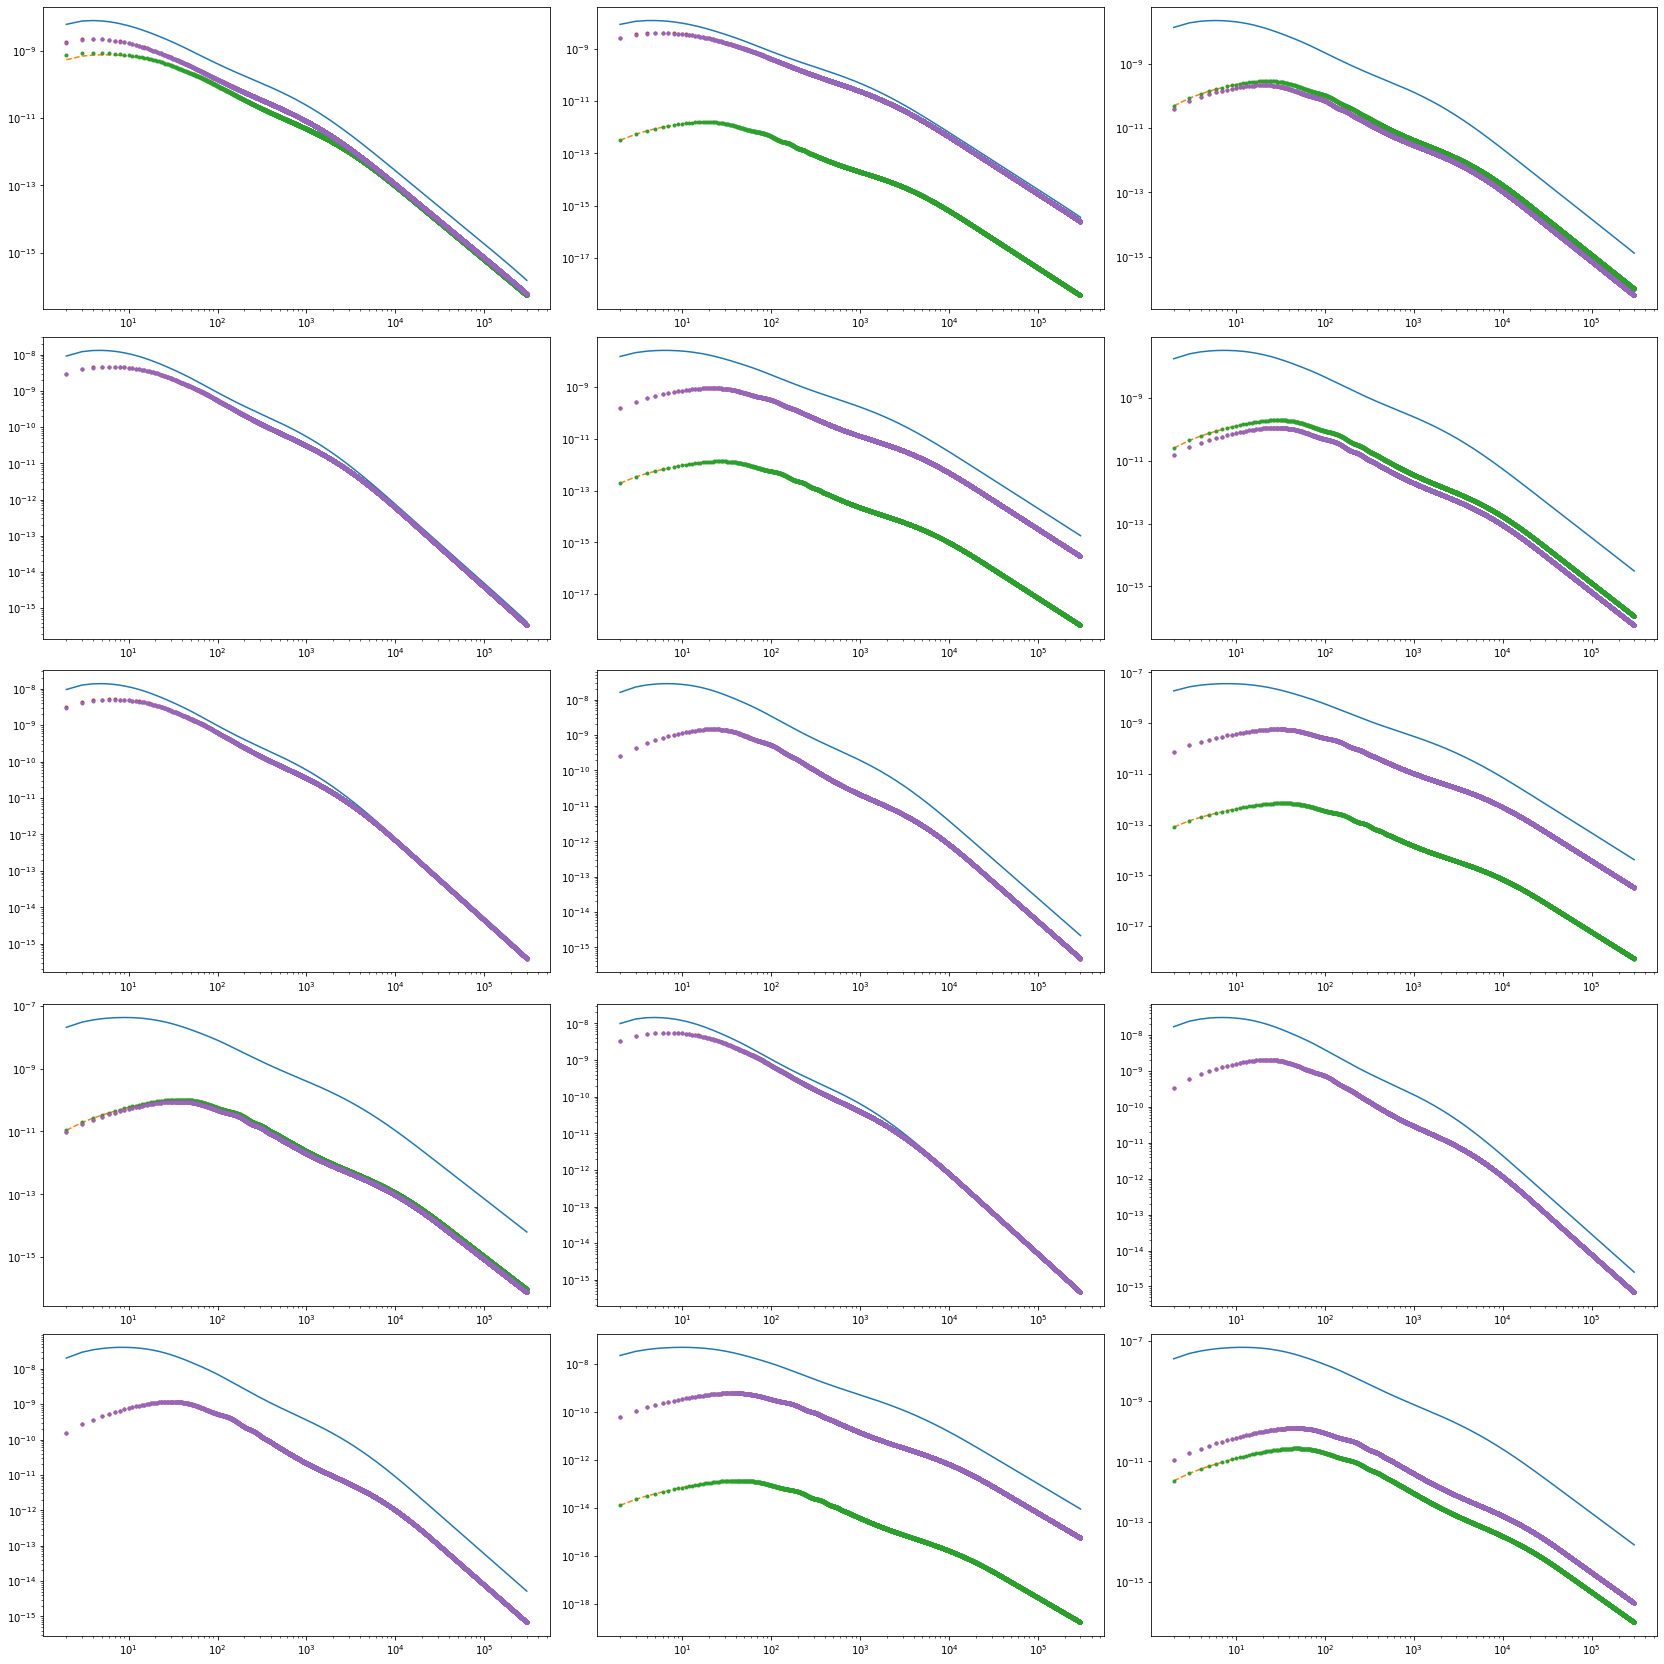

In [28]:
k=ell
figsize = (23, 23)
fig =plt.figure(figsize=figsize, constrained_layout=True)
cols = 3
rows =5
axs = fig.subplots(rows, cols)
axs = trim_axs(axs, len(cls['GG']))
for ax, pi in zip(axs, cls['GG']):
    ax.loglog(ell, pi,label='No IA')
for ax, px in zip(axs, cls['II,NLA']):
    ax.loglog(ell, px,'--',label='II,NLA')
for ax, pj in zip(axs, cls['II']):
    ax.loglog(ell, pj,'.',label='II')
for ax, pjk in zip(axs, cls['GI']):
    ax.loglog(ell,-pjk,'.',label='-GI')
for ax, pjj in zip(axs, cls['GI,NLA']):
    ax.loglog(ell, -pjj,'.',label='-GI,NLA')

#     plt.xlabel(r'$\\ell$', fontsize=15)\n",
#     plt.ylabel(r'$\\C_{\\ell}(\\ell)$', fontsize=15)\n",
# legend(loc='upper right')"